# Bài tập lớn
Họ tên: Nguyễn Minh Lộc — MSSV: 2570756 — Nhóm: ...

Họ tên: Nguyễn Văn Hậu — MSSV: ... — Nhóm: ...

**Mục tiêu:** Dùng thông tin một tình huống để dự đoán người được hỏi có chấp nhận coupon không. `Y=1`: có; `Y=0`: không.

**Dữ liệu:** In-Vehicle Coupon Recommendation, UCI; 12.684 dòng, 25 đặc trưng + 1 nhãn. Có missing tự nhiên, cột chữ và cột số. Nguồn: https://archive.ics.uci.edu/dataset/603/in+vehicle+coupon+recommendation — DOI 10.24432/C5GS4P, CC BY 4.0. Đây là dữ liệu khảo sát, không phải giao dịch thực tế.

**Cách chạy Colab:** upload notebook và file `in-vehicle-coupon-recommendation.csv` vào Colab, rồi chọn **Runtime → Run all**. Nếu chưa upload CSV, ô đọc dữ liệu sẽ tải tự động từ UCI. Không cần GPU.



## 1. Import thư viện
Pandas xử lý bảng; Matplotlib vẽ hình; Scikit-learn có sẵn các thuật toán học máy. Không cần tự lập trình công thức huấn luyện.

In [49]:
import os
import zipfile
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

os.makedirs('ket_qua', exist_ok=True)

## 2. Đọc file CSV
`shape[0]` là số dòng; `shape[1]` là số cột. Khối `if` chỉ tải dữ liệu nếu chưa có file, có thể đọc sau khi đã hiểu `pd.read_csv`.

In [50]:
ten_file = 'in-vehicle-coupon-recommendation.csv'
if not os.path.exists(ten_file):
    url = 'https://archive.ics.uci.edu/static/public/603/in+vehicle+coupon+recommendation.zip'
    urllib.request.urlretrieve(url, 'du_lieu.zip')
    with zipfile.ZipFile('du_lieu.zip') as tep_zip:
        tep_zip.extract(ten_file, '.')

df = pd.read_csv(ten_file)
print('Số dòng:', df.shape[0])
print('Số cột:', df.shape[1])
print('Số ô thiếu:', df.isna().sum().sum())
print(df.head().to_string())


Số dòng: 12684
Số cột: 26
Số ô thiếu: 13370
       destination  passanger weather  temperature  time                 coupon expiration  gender age      maritalStatus  has_children                 education  occupation           income  car    Bar CoffeeHouse CarryAway RestaurantLessThan20 Restaurant20To50  toCoupon_GEQ5min  toCoupon_GEQ15min  toCoupon_GEQ25min  direction_same  direction_opp  Y
0  No Urgent Place      Alone   Sunny           55   2PM        Restaurant(<20)         1d  Female  21  Unmarried partner             1  Some college - no degree  Unemployed  $37500 - $49999  NaN  never       never       NaN                  4~8              1~3                 1                  0                  0               0              1  1
1  No Urgent Place  Friend(s)   Sunny           80  10AM           Coffee House         2h  Female  21  Unmarried partner             1  Some college - no degree  Unemployed  $37500 - $49999  NaN  never       never       NaN                  4~8     

## 3. Xem kiểu dữ liệu và bỏ dòng trùng
`object` thường là chữ, `int64` là số nguyên. `age` và `income` chứa các khoảng như `50plus`, nên giữ là biến phân loại. Chỉ bỏ dòng trùng hoàn toàn, chưa xóa các dòng có missing.

In [51]:
print(df.dtypes)
print('Số dòng trùng:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Số dòng còn lại:', len(df))


destination             object
passanger               object
weather                 object
temperature              int64
time                    object
coupon                  object
expiration              object
gender                  object
age                     object
maritalStatus           object
has_children             int64
education               object
occupation              object
income                  object
car                     object
Bar                     object
CoffeeHouse             object
CarryAway               object
RestaurantLessThan20    object
Restaurant20To50        object
toCoupon_GEQ5min         int64
toCoupon_GEQ15min        int64
toCoupon_GEQ25min        int64
direction_same           int64
direction_opp            int64
Y                        int64
dtype: object
Số dòng trùng: 74
Số dòng còn lại: 12610


## 4. Chia train, validation, test
- **Train 60%:** học cách xử lý dữ liệu và huấn luyện mô hình.
- **Validation 20%:** so sánh, chọn mô hình.
- **Test 20%:** đánh giá cuối, không dùng để chọn lại mô hình.

Tách 20% test trước; 25% của 80% còn lại là 20% toàn bộ dữ liệu. `random_state=42` giúp lặp lại cách chia; `stratify=y` giữ tỷ lệ lớp gần giống nhau.

**Giới hạn của bản cơ bản:** chia ngẫu nhiên theo dòng dễ học, nhưng cùng người trả lời có thể xuất hiện ở nhiều tập qua các tình huống khác nhau. CSV không có ID người trả lời. Điểm số có thể lạc quan và không so sánh trực tiếp với bản trước chia theo nhóm hồ sơ. Không khẳng định khả năng dự đoán cho người hoàn toàn mới.


In [52]:
X = df.drop(columns=['Y'])  # Đặc trưng đầu vào
y = df['Y']                 # Nhãn cần dự đoán

X_tam, X_test, y_tam, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tam, y_tam, test_size=0.25, random_state=42, stratify=y_tam)

# copy() để chỉnh sửa từng tập riêng
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()
print('Train:', len(X_train))
print('Validation:', len(X_val))
print('Test:', len(X_test))


Train: 7566
Validation: 2522
Test: 2522


## 5. EDA: missing values và tỷ lệ lớp
Phân tích chi tiết trên train để chưa sử dụng thông tin test. `.isna().sum()` đếm số ô thiếu từng cột; `.value_counts()` đếm từng nhãn.


car                     7502
Bar                       62
CoffeeHouse              113
CarryAway                 90
RestaurantLessThan20      89
Restaurant20To50         103
dtype: int64


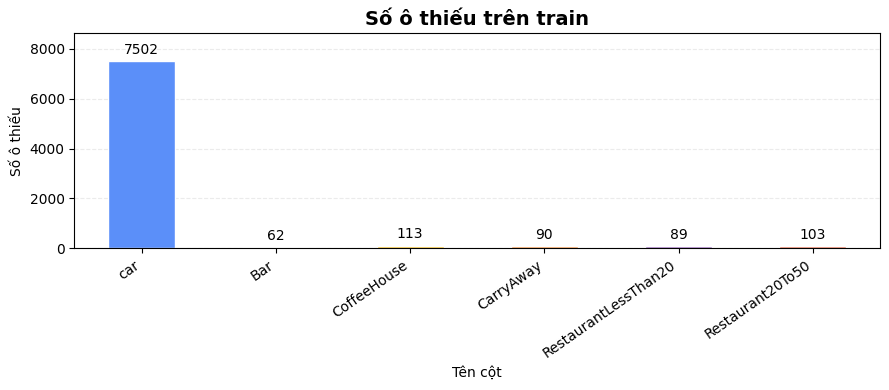

Tỷ lệ từng nhãn:
Y
1    0.568
0    0.432
Name: proportion, dtype: float64


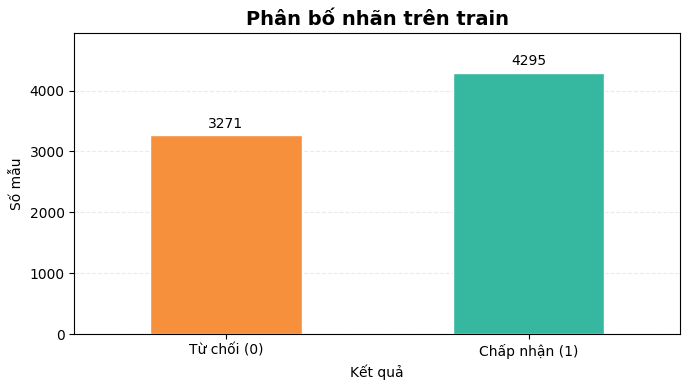

Nhận xét: tỷ lệ chấp nhận trên train là 56.8%; hai lớp chỉ lệch nhẹ.


In [53]:
# 1. Biểu đồ missing values
so_o_thieu = X_train.isna().sum()
cot_thieu = so_o_thieu[so_o_thieu > 0]

print(cot_thieu)

mau_missing = [
    '#5B8FF9', '#61DDAA', '#F6BD16',
    '#F6903D', '#9661BC', '#E8684A'
]

ax = cot_thieu.plot.bar(
    figsize=(9, 4),
    color=mau_missing,
    edgecolor='white'
)

# Hiển thị số lượng trên từng cột
for nhom_cot in ax.containers:
    ax.bar_label(nhom_cot, padding=3)

plt.title('Số ô thiếu trên train', fontsize=14, fontweight='bold')
plt.xlabel('Tên cột')
plt.ylabel('Số ô thiếu')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, cot_thieu.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ket_qua/01_missing.png', dpi=150)
plt.show()


# 2. Biểu đồ số lượng từng nhãn
print('Tỷ lệ từng nhãn:')
print(y_train.value_counts(normalize=True).round(3))

so_luong_nhan = y_train.value_counts().sort_index()

ax = so_luong_nhan.plot.bar(
    figsize=(7, 4),
    color=['#F6903D', '#36B7A0'],
    edgecolor='white'
)

for nhom_cot in ax.containers:
    ax.bar_label(nhom_cot, padding=3)

plt.title('Phân bố nhãn trên train', fontsize=14, fontweight='bold')
plt.xlabel('Kết quả')
plt.ylabel('Số mẫu')
plt.xticks(
    ticks=[0, 1],
    labels=['Từ chối (0)', 'Chấp nhận (1)'],
    rotation=0
)
plt.ylim(0, so_luong_nhan.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ket_qua/02_nhan.png', dpi=150)
plt.show()

print(
    f'Nhận xét: tỷ lệ chấp nhận trên train là '
    f'{y_train.mean():.1%}; hai lớp chỉ lệch nhẹ.'
)

## 6. Target so với hai đặc trưng
Vì Y chỉ nhận 0 hoặc 1, trung bình Y chính là tỷ lệ chấp nhận. Ví dụ `[1, 0, 1, 1]` có trung bình 0,75, tức 75% chấp nhận.

**Câu hỏi:** loại coupon và thời hạn nào có tỷ lệ chấp nhận cao hơn? Vòng `for` vẽ cùng kiểu hình cho hai cột; có bảng số mẫu, tỷ lệ và kết luận ngay dưới hình.


                        mean  count
coupon                             
Bar                    0.416   1182
Restaurant(20-50)      0.456    924
Coffee House           0.500   2428
Restaurant(<20)        0.700   1656
Carry out & Take away  0.733   1376


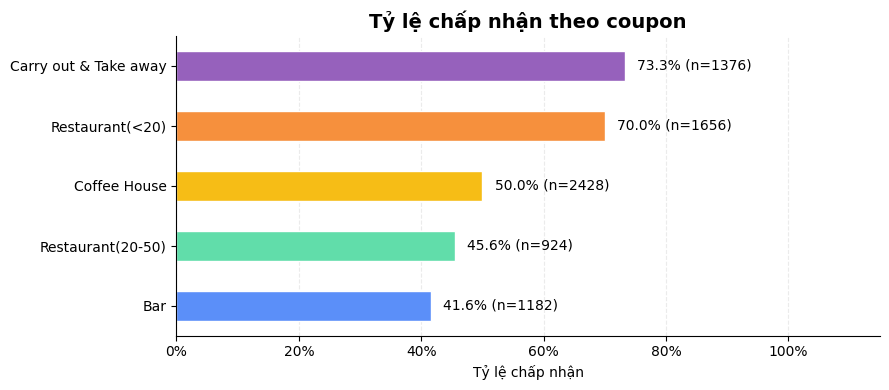

Kết luận: coupon: Carry out & Take away đạt 73.3%, so với Bar đạt 41.6%.
             mean  count
expiration              
2h          0.493   3320
1d          0.626   4246


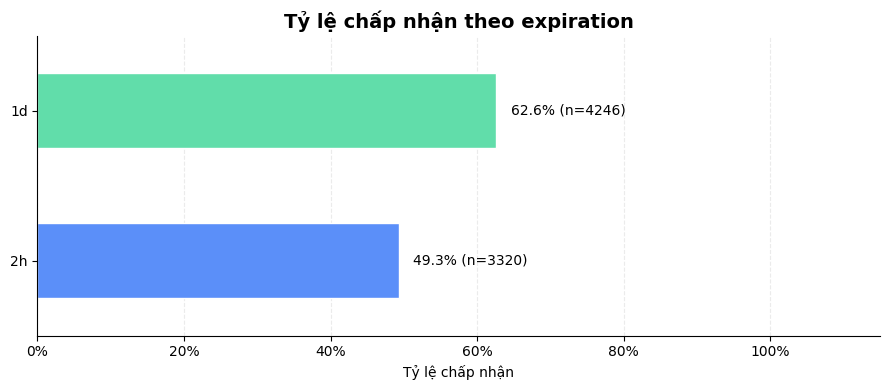

Kết luận: expiration: 1d đạt 62.6%, so với 2h đạt 49.3%.


In [54]:
train = X_train.copy()
train['Y'] = y_train
nhan_xet_eda = []

mau_sac = ['#5B8FF9', '#61DDAA', '#F6BD16', '#F6903D', '#9661BC']

for cot in ['coupon', 'expiration']:
    bang = train.groupby(cot)['Y'].agg(['mean', 'count'])
    bang = bang.sort_values('mean')
    print(bang.round(3))

    ax = bang['mean'].plot.barh(
        figsize=(9, 4),
        color=mau_sac,
        edgecolor='white'
    )

    # Ghi tỷ lệ và số mẫu bên cạnh mỗi thanh
    for i in range(len(bang)):
        ty_le = bang['mean'].iloc[i]
        so_mau = bang['count'].iloc[i]

        ax.text(
            ty_le + 0.02,
            i,
            f'{ty_le:.1%} (n={so_mau})',
            va='center',
            fontsize=10
        )

    plt.title(
        'Tỷ lệ chấp nhận theo ' + cot,
        fontsize=14,
        fontweight='bold'
    )
    plt.xlabel('Tỷ lệ chấp nhận')
    plt.ylabel('')

    # Hiển thị trục ngang theo phần trăm
    plt.xticks(
        [0, 0.2, 0.4, 0.6, 0.8, 1],
        ['0%', '20%', '40%', '60%', '80%', '100%']
    )
    plt.xlim(0, 1.15)

    plt.grid(axis='x', linestyle='--', alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('ket_qua/03_' + cot + '.png', dpi=150)
    plt.show()

    nhan_xet = (
        f"{cot}: {bang.index[-1]} đạt {bang['mean'].iloc[-1]:.1%}, "
        f"so với {bang.index[0]} đạt {bang['mean'].iloc[0]:.1%}."
    )
    print('Kết luận:', nhan_xet)
    nhan_xet_eda.append(nhan_xet)

## 7. Bỏ cột quá thiếu hoặc không thay đổi
Dùng vòng lặp đơn giản: nếu cột thiếu trên 95% hoặc chỉ có một giá trị trên train thì bỏ cột đó ở cả ba tập. Không học quyết định bỏ cột từ validation/test.


In [55]:
cot_bo = []
for cot in X_train.columns:
    ty_le_thieu = X_train[cot].isna().mean()
    so_gia_tri = X_train[cot].nunique()
    if ty_le_thieu > 0.95 or so_gia_tri <= 1:
        cot_bo.append(cot)

print('Các cột bỏ:', cot_bo)
X_train = X_train.drop(columns=cot_bo)
X_val = X_val.drop(columns=cot_bo)
X_test = X_test.drop(columns=cot_bo)


Các cột bỏ: ['car', 'toCoupon_GEQ5min']


## 8. Điền giá trị thiếu
- Cột số: điền **trung vị (median)** của train.
- Cột chữ: điền **giá trị xuất hiện nhiều nhất (mode)** của train.

`mode()` trả về danh sách các giá trị phổ biến; `[0]` lấy giá trị đầu tiên. Validation/test dùng cùng giá trị điền học từ train để tránh rò rỉ dữ liệu.


In [56]:
cot_so = X_train.select_dtypes(include='number').columns.tolist()
cot_chu = X_train.select_dtypes(include='object').columns.tolist()

for cot in cot_so:
    gia_tri_dien = X_train[cot].median()
    X_train[cot] = X_train[cot].fillna(gia_tri_dien)
    X_val[cot] = X_val[cot].fillna(gia_tri_dien)
    X_test[cot] = X_test[cot].fillna(gia_tri_dien)

for cot in cot_chu:
    gia_tri_dien = X_train[cot].mode()[0]
    X_train[cot] = X_train[cot].fillna(gia_tri_dien)
    X_val[cot] = X_val[cot].fillna(gia_tri_dien)
    X_test[cot] = X_test[cot].fillna(gia_tri_dien)

print('Missing còn lại:', X_train.isna().sum().sum(),
      X_val.isna().sum().sum(), X_test.isna().sum().sum())


Missing còn lại: 0 0 0


## 9. Kiểm tra outlier
Chỉ kiểm tra `temperature`: các cột số còn lại chủ yếu là 0/1, không phù hợp để xóa outlier theo IQR.

Q1 và Q3 là mốc 25% và 75%; IQR = Q3 − Q1. Ngoài khoảng `[Q1 − 1,5×IQR; Q3 + 1,5×IQR]` được gắn cờ để xem xét. Nhiệt độ chỉ có vài mức khảo sát hợp lệ, nên không xóa máy móc.


In [57]:
print(X_train['temperature'].describe())
q1 = X_train['temperature'].quantile(0.25)
q3 = X_train['temperature'].quantile(0.75)
iqr = q3 - q1
can_duoi = q1 - 1.5 * iqr
can_tren = q3 + 1.5 * iqr
outlier = (X_train['temperature'] < can_duoi) | (X_train['temperature'] > can_tren)
print('Số mẫu ngoài ngưỡng IQR:', outlier.sum())
print('Các mức nhiệt độ:', sorted(X_train['temperature'].unique()))
print('Quyết định: giữ các mức nhiệt độ hợp lệ của khảo sát.')


count    7566.000000
mean       63.333333
std        19.103618
min        30.000000
25%        55.000000
50%        80.000000
75%        80.000000
max        80.000000
Name: temperature, dtype: float64
Số mẫu ngoài ngưỡng IQR: 0
Các mức nhiệt độ: [np.int64(30), np.int64(55), np.int64(80)]
Quyết định: giữ các mức nhiệt độ hợp lệ của khảo sát.


## 10. Encoding: đổi cột chữ thành số
`pd.get_dummies()` tạo cột 0/1. Ví dụ `weather=Sunny` tạo cột `weather_Sunny`.

Các tập có thể gặp nhóm khác nhau, nên dùng `reindex()` để validation/test có đúng các cột của train. Nhóm chưa gặp ở train được biểu diễn bằng các cột của biến đó đều bằng 0.


In [58]:
X_train_ma = pd.get_dummies(X_train, columns=cot_chu, dtype=int)
X_val_ma = pd.get_dummies(X_val, columns=cot_chu, dtype=int)
X_test_ma = pd.get_dummies(X_test, columns=cot_chu, dtype=int)

X_val_ma = X_val_ma.reindex(columns=X_train_ma.columns, fill_value=0)
X_test_ma = X_test_ma.reindex(columns=X_train_ma.columns, fill_value=0)
print('Số cột sau encoding:', X_train_ma.shape[1])
print(X_train_ma.head().to_string())


Số cột sau encoding: 108
      temperature  has_children  toCoupon_GEQ15min  toCoupon_GEQ25min  direction_same  direction_opp  destination_Home  destination_No Urgent Place  destination_Work  passanger_Alone  passanger_Friend(s)  passanger_Kid(s)  passanger_Partner  weather_Rainy  weather_Snowy  weather_Sunny  time_10AM  time_10PM  time_2PM  time_6PM  time_7AM  coupon_Bar  coupon_Carry out & Take away  coupon_Coffee House  coupon_Restaurant(20-50)  coupon_Restaurant(<20)  expiration_1d  expiration_2h  gender_Female  gender_Male  age_21  age_26  age_31  age_36  age_41  age_46  age_50plus  age_below21  maritalStatus_Divorced  maritalStatus_Married partner  maritalStatus_Single  maritalStatus_Unmarried partner  maritalStatus_Widowed  education_Associates degree  education_Bachelors degree  education_Graduate degree (Masters or Doctorate)  education_High School Graduate  education_Some High School  education_Some college - no degree  occupation_Architecture & Engineering  occupation_Arts D

## 11. Scaling: chuẩn hóa các cột số
StandardScaler tính `(x − trung bình train) / độ lệch chuẩn train`. **fit_transform** vừa học vừa biến đổi train; **transform** chỉ áp dụng cho validation/test. Các cột one-hot giữ nguyên 0/1.

Lưu nhiệt độ trước scaling để vẽ đối chiếu.


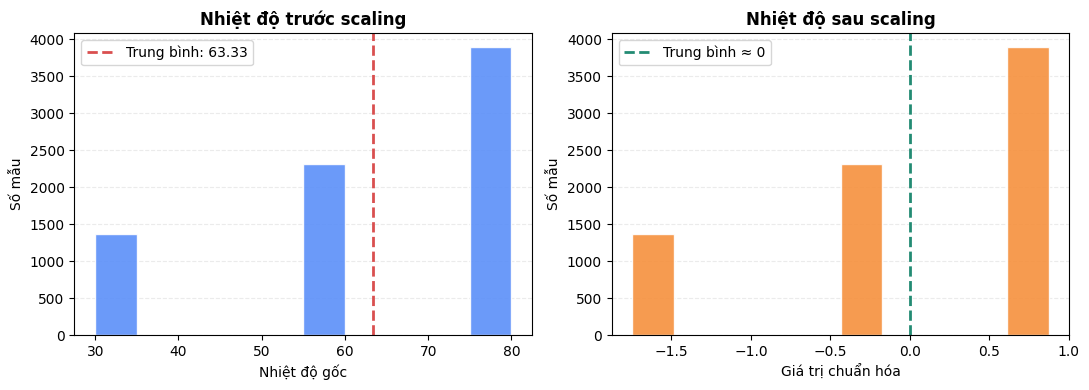

Trung bình: 63.33 → -0.00
Kết luận: scaling đưa dữ liệu về thang đo có trung bình xấp xỉ 0; số mẫu và dạng phân phối không thay đổi.


In [59]:
nhiet_do_truoc = X_train_ma['temperature'].copy()

scaler = StandardScaler()
X_train_ma[cot_so] = scaler.fit_transform(X_train_ma[cot_so])
X_val_ma[cot_so] = scaler.transform(X_val_ma[cot_so])
X_test_ma[cot_so] = scaler.transform(X_test_ma[cot_so])

plt.figure(figsize=(11, 4))

# 1. Trước scaling
plt.subplot(1, 2, 1)
plt.hist(
    nhiet_do_truoc,
    bins=10,
    color='#5B8FF9',
    edgecolor='white',
    alpha=0.9
)
plt.axvline(
    nhiet_do_truoc.mean(),
    color='#D94F4F',
    linestyle='--',
    linewidth=2,
    label=f'Trung bình: {nhiet_do_truoc.mean():.2f}'
)
plt.title('Nhiệt độ trước scaling', fontweight='bold')
plt.xlabel('Nhiệt độ gốc')
plt.ylabel('Số mẫu')
plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.gca().set_axisbelow(True)
plt.legend()

# 2. Sau scaling
plt.subplot(1, 2, 2)
plt.hist(
    X_train_ma['temperature'],
    bins=10,
    color='#F6903D',
    edgecolor='white',
    alpha=0.9
)
plt.axvline(
    X_train_ma['temperature'].mean(),
    color='#238B73',
    linestyle='--',
    linewidth=2,
    label='Trung bình ≈ 0'
)
plt.title('Nhiệt độ sau scaling', fontweight='bold')
plt.xlabel('Giá trị chuẩn hóa')
plt.ylabel('Số mẫu')
plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.gca().set_axisbelow(True)
plt.legend()

plt.tight_layout()
plt.savefig('ket_qua/04_scaling.png', dpi=150)
plt.show()

print(
    f"Trung bình: {nhiet_do_truoc.mean():.2f} "
    f"→ {X_train_ma['temperature'].mean():.2f}"
)
print(
    'Kết luận: scaling đưa dữ liệu về thang đo có trung bình '
    'xấp xỉ 0; số mẫu và dạng phân phối không thay đổi.'
)

## 12. Huấn luyện và so sánh 8 cấu hình mô hình
So sánh Logistic Regression, cây sâu 3, cây sâu 8, KNN, Naive Bayes, Random Forest, SVM và XGBoost.

- **KNN:** dự đoán dựa trên 5 mẫu gần nhất.
- **Naive Bayes:** dự đoán bằng xác suất; dùng GaussianNB như một baseline đơn giản.
- **Random Forest:** kết hợp nhiều cây quyết định.
- **SVM:** tìm ranh giới phân chia hai lớp.
- **XGBoost:** xây cây lần lượt để cải thiện sai số của các cây trước.

Dòng `%pip` cài XGBoost trong môi trường notebook; cần internet nếu chưa có thư viện. SVM có thể chạy lâu hơn.

Cùng dữ liệu train và validation cho mọi mô hình. Chọn Macro-F1 validation cao nhất; chưa dùng test. Các cấu hình là ví dụ cơ bản, chưa tối ưu tham số. Tên cột có ký tự `<`, `[` hoặc `]` được đổi đồng nhất ở ba tập để XGBoost đọc được; giá trị dữ liệu không đổi.


In [60]:
# Cài thư viện XGBoost cho Colab / Jupyter
%pip install -q xgboost

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Đổi ký tự đặc biệt trong tên cột để tương thích với XGBoost
for bang in [X_train_ma, X_val_ma, X_test_ma]:
    bang.columns = bang.columns.str.replace('<', 'lt', regex=False)
    bang.columns = bang.columns.str.replace('[', '(', regex=False)
    bang.columns = bang.columns.str.replace(']', ')', regex=False)

mo_hinh = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Cây độ sâu 3': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Cây độ sâu 8': DecisionTreeClassifier(max_depth=8, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=2),
    'SVM': SVC(kernel='rbf'),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric='logloss', random_state=42, n_jobs=2)
}

ket_qua = []
for ten in mo_hinh:
    print('Đang huấn luyện:', ten)
    model = mo_hinh[ten]
    model.fit(X_train_ma, y_train)
    du_doan = model.predict(X_val_ma)
    accuracy = accuracy_score(y_val, du_doan)
    f1 = f1_score(y_val, du_doan, average='macro')
    ket_qua.append([ten, accuracy, f1])

bang_val = pd.DataFrame(ket_qua, columns=['Mô hình', 'Accuracy', 'Macro-F1'])
bang_val = bang_val.sort_values('Macro-F1', ascending=False)
print(bang_val.round(4).to_string(index=False))

dong_tot_nhat = bang_val['Macro-F1'].idxmax()
ten_tot_nhat = bang_val.loc[dong_tot_nhat, 'Mô hình']
print('Mô hình được chọn:', ten_tot_nhat)


Đang huấn luyện: Logistic Regression
Đang huấn luyện: Cây độ sâu 3
Đang huấn luyện: Cây độ sâu 8
Đang huấn luyện: KNN
Đang huấn luyện: Naive Bayes
Đang huấn luyện: Random Forest
Đang huấn luyện: SVM
Đang huấn luyện: XGBoost
            Mô hình  Accuracy  Macro-F1
                SVM    0.7339    0.7226
            XGBoost    0.7324    0.7193
      Random Forest    0.7189    0.7009
       Cây độ sâu 8    0.7022    0.6900
Logistic Regression    0.6903    0.6795
                KNN    0.6653    0.6552
        Naive Bayes    0.6221    0.6196
       Cây độ sâu 3    0.6416    0.5802
Mô hình được chọn: SVM


## 13. Biểu đồ so sánh và nhận xét tự động
Biểu đồ thanh ngang giúp đọc tên 8 cấu hình. Nhãn trên thanh thể hiện điểm chính xác.

**Câu hỏi:** mô hình được chọn và XGBoost có Macro-F1 validation cao hơn Logistic Regression bao nhiêu? Khi chỉ thay độ sâu cây từ 3 lên 8, kết quả thay đổi thế nào?

Bảng, hình, nhận xét và báo cáo dùng chung kết quả `bang_val`. Giá trị chênh lệch dương nghĩa là cao hơn baseline; âm nghĩa là thấp hơn. Không mặc định XGBoost luôn tốt nhất.


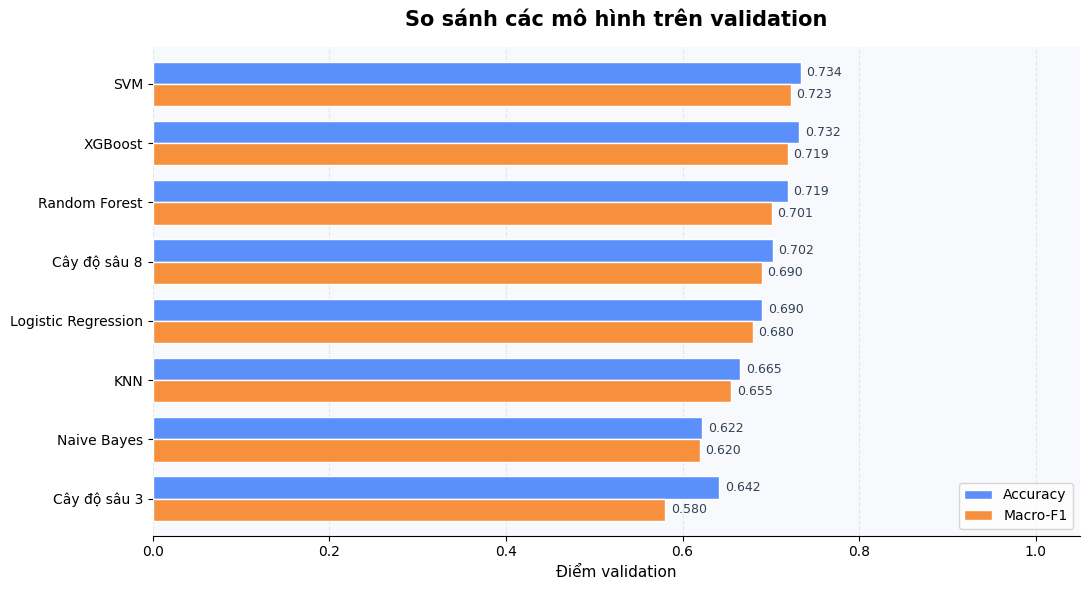

In [64]:
# Vẽ biểu đồ với hai màu phân biệt hai chỉ số
ax = bang_val.plot.barh(
    x='Mô hình',
    y=['Accuracy', 'Macro-F1'],
    figsize=(11, 6),
    color=['#5B8FF9', '#F6903D'],
    edgecolor='white',
    width=0.75
)

ax.invert_yaxis()
ax.set_facecolor('#F7F9FC')

plt.title(
    'So sánh các mô hình trên validation',
    fontsize=15,
    fontweight='bold',
    pad=15
)
plt.xlabel('Điểm validation', fontsize=11)
plt.ylabel('')
plt.xlim(0, 1.05)

# Ghi điểm lên từng thanh
for nhom_thanh in ax.containers:
    ax.bar_label(
        nhom_thanh,
        fmt='%.3f',
        padding=4,
        fontsize=9,
        color='#334155'
    )

# Thêm lưới nhẹ để dễ đối chiếu điểm
plt.grid(axis='x', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

# Ẩn các đường viền không cần thiết
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('ket_qua/05_so_sanh.png', dpi=150)
plt.show()

## 14. Đánh giá mô hình đã chọn trên test
Để code ngắn, giữ mô hình đã học trên train; không huấn luyện lại. Chỉ đánh giá mô hình đã chọn bằng validation. Trong confusion matrix, hàng là nhãn thật, cột là nhãn dự đoán; các ô trên đường chéo là dự đoán đúng.


Mô hình: SVM
Accuracy test: 0.7276
Macro-F1 test: 0.7178


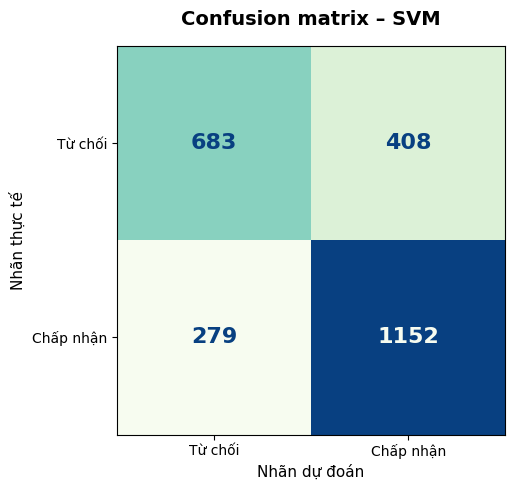

Kết luận: mô hình dự đoán đúng 72.8% tình huống trong test.


In [65]:
model_tot_nhat = mo_hinh[ten_tot_nhat]
du_doan_test = model_tot_nhat.predict(X_test_ma)

accuracy_test = accuracy_score(y_test, du_doan_test)
f1_test = f1_score(y_test, du_doan_test, average='macro')

print('Mô hình:', ten_tot_nhat)
print(f'Accuracy test: {accuracy_test:.4f}')
print(f'Macro-F1 test: {f1_test:.4f}')

# Tạo biểu đồ
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    du_doan_test,
    display_labels=['Từ chối', 'Chấp nhận'],
    cmap='GnBu',         # Màu xanh lá nhạt → xanh dương đậm
    colorbar=False,
    values_format='d',  # Hiển thị số mẫu dạng số nguyên
    ax=ax
)

plt.title(
    'Confusion matrix – ' + ten_tot_nhat,
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel('Nhãn dự đoán', fontsize=11)
plt.ylabel('Nhãn thực tế', fontsize=11)

# Làm số trong các ô rõ hơn
for chu in ax.texts:
    chu.set_fontsize(16)
    chu.set_fontweight('bold')

plt.tight_layout()
plt.savefig('ket_qua/06_confusion_matrix.png', dpi=150)
plt.show()

print(
    f'Kết luận: mô hình dự đoán đúng '
    f'{accuracy_test:.1%} tình huống trong test.'
)

## 15. Lưu bảng và báo cáo ngắn
Các số trong báo cáo lấy từ biến đã tính nên khớp với bảng/hình. File được lưu trong thư mục `ket_qua`. Đây cũng là ví dụ cơ bản về ghi file văn bản bằng Python.


In [66]:
from IPython.display import display

# Tạo bảng kết quả test
bang_test = pd.DataFrame(
    [[ten_tot_nhat, accuracy_test, f1_test]],
    columns=['Mô hình', 'Accuracy', 'Macro-F1']
)

print('BÁO CÁO: DỰ ĐOÁN CHẤP NHẬN COUPON')
print('=' * 60)

# 1. Thông tin dữ liệu
print('\n1. THÔNG TIN DỮ LIỆU')
print('Nguồn: UCI, DOI 10.24432/C5GS4P, CC BY 4.0.')
print(f'Sau bỏ trùng: {len(df)} dòng, {df.shape[1]} cột.')
print(f'Train: {len(X_train)} mẫu')
print(f'Validation: {len(X_val)} mẫu')
print(f'Test: {len(X_test)} mẫu')
print('Chia ngẫu nhiên theo dòng, giữ tỷ lệ nhãn; random_state=42.')

# 2. Nhận xét EDA
print('\n2. NHẬN XÉT DỮ LIỆU')
for nhan_xet in nhan_xet_eda:
    print('-', nhan_xet)

# 3. So sánh mô hình trên validation
print('\n3. KẾT QUẢ VALIDATION')
display(bang_val.round(4))

# 4. Thí nghiệm mở rộng
print('\n4. NHẬN XÉT SO SÁNH')
print(nhan_xet_mo_rong)

# 5. Đánh giá trên test
print('\n5. KẾT QUẢ TEST')
display(bang_test.round(4))

print(f'Mô hình được chọn bằng validation: {ten_tot_nhat}')
print(f'Mô hình dự đoán đúng {accuracy_test:.1%} tình huống trên test.')

# 6. Hạn chế và hướng mở rộng
print('\n6. HẠN CHẾ')
print('- Dữ liệu là khảo sát giả định, không phải giao dịch thực tế.')
print('- Cùng người trả lời có thể xuất hiện ở nhiều tập.')
print('- Mới đánh giá trên một lần chia dữ liệu.')

print('\n7. HƯỚNG MỞ RỘNG')
print('- Chia dữ liệu theo người trả lời khi có ID.')
print('- Thử các tham số khác và so sánh trên validation.')
print('- Thu thập thêm dữ liệu thực tế để kiểm tra mô hình.')

BÁO CÁO: DỰ ĐOÁN CHẤP NHẬN COUPON

1. THÔNG TIN DỮ LIỆU
Nguồn: UCI, DOI 10.24432/C5GS4P, CC BY 4.0.
Sau bỏ trùng: 12610 dòng, 26 cột.
Train: 7566 mẫu
Validation: 2522 mẫu
Test: 2522 mẫu
Chia ngẫu nhiên theo dòng, giữ tỷ lệ nhãn; random_state=42.

2. NHẬN XÉT DỮ LIỆU
- coupon: Carry out & Take away đạt 73.3%, so với Bar đạt 41.6%.
- expiration: 1d đạt 62.6%, so với 2h đạt 49.3%.

3. KẾT QUẢ VALIDATION


,Mô hình,Accuracy,Macro-F1
6,SVM,0.7339,0.7226
7,XGBoost,0.7324,0.7193
5,Random Forest,0.7189,0.7009
2,Cây độ sâu 8,0.7022,0.6900
0,Logistic Regression,0.6903,0.6795
3,KNN,0.6653,0.6552
4,Naive Bayes,0.6221,0.6196
1,Cây độ sâu 3,0.6416,0.5802



4. NHẬN XÉT SO SÁNH
SVM được chọn: Macro-F1=0.7226; Logistic Regression=0.6795; chênh lệch=+0.0431. XGBoost=0.7193; chênh so với baseline=+0.0398. Cây sâu 3=0.5802; cây sâu 8=0.6900; chênh lệch (sâu 8 trừ sâu 3)=+0.1098.

5. KẾT QUẢ TEST


,Mô hình,Accuracy,Macro-F1
0,SVM,0.7276,0.7178


Mô hình được chọn bằng validation: SVM
Mô hình dự đoán đúng 72.8% tình huống trên test.

6. HẠN CHẾ
- Dữ liệu là khảo sát giả định, không phải giao dịch thực tế.
- Cùng người trả lời có thể xuất hiện ở nhiều tập.
- Mới đánh giá trên một lần chia dữ liệu.

7. HƯỚNG MỞ RỘNG
- Chia dữ liệu theo người trả lời khi có ID.
- Thử các tham số khác và so sánh trên validation.
- Thu thập thêm dữ liệu thực tế để kiểm tra mô hình.
